<a href="https://colab.research.google.com/github/saraeastough/SCI1500-Sara-Eastough-public/blob/main/SCIE1500Materials/Week_9/LabFiles/Week09_Lab_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 9 Lab — Probability, Bayes' Theorem, and Medical Testing
**SCIE1500 — Analytical Methods for Scientists (UWA)**

**Lab format:** Work in your groups. Run all code cells in order, fill in the written prompts.

---
**This week:** We use probability and Bayes' theorem to evaluate the real-world performance of diagnostic tests — a critical skill in public health and clinical science.

---
## 📋 Scientific Scenario: A Positive Result Is Not a Diagnosis

![Diagnostic testing: population grid and PPV vs prevalence curve](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_9/images/W9_bayes_testing.svg?raw=1)

During a COVID-19 wave, health authorities use a rapid antigen test with the following properties:

- **Sensitivity** (true positive rate): 85% — if you have COVID, the test detects it 85% of the time.
- **Specificity** (true negative rate): 95% — if you do not have COVID, the test correctly gives a negative 95% of the time.
- **Community prevalence**: 2% of the population currently has COVID.

At first glance, 85% sensitivity and 95% specificity sound highly reliable. But a person who sees a positive result needs a different question answered: **given this result, how likely is it that I actually have COVID?** That probability depends not only on the test, but also on how common COVID is in the tested population.

**Decision question:** At 2% prevalence, should a positive rapid-test result trigger a major clinical or public-health decision on its own, or should it be confirmed? Build your answer from the expected counts, not just from the test's percentages.

---
## 🎯 Group Task & Learning Objectives

| Part | Topic | Time |
|------|-------|------|
| A | Bayes' theorem: algebra and intuition | ~25 min |
| B | Python calculation and verification | ~20 min |
| C | Sensitivity analysis: how prevalence changes everything | ~15 min |

By the end you should be able to apply Bayes' theorem to diagnostic testing, distinguish sensitivity and specificity from positive predictive value (PPV), interpret negative predictive value (NPV), and explain why prevalence changes what a positive result means.

**Lab focus:** Record one probability statement, one count from the 10,000-person table, and one implication for a testing decision. Together, they form a complete evidence-based explanation.

In [ ]:
# Run this cell first — loads libraries for today's lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Test parameters
sensitivity  = 0.85   # P(T+ | Disease)
specificity  = 0.95   # P(T- | No Disease)
prevalence   = 0.02   # P(Disease)

false_pos_rate = 1 - specificity   # P(T+ | No Disease)

print("Test characteristics:")
print(f"  Sensitivity:       {sensitivity:.0%}")
print(f"  Specificity:       {specificity:.0%}")
print(f"  False positive:    {false_pos_rate:.0%}")
print(f"  Prevalence:        {prevalence:.0%}")

Test characteristics:
  Sensitivity:       85%
  Specificity:       95%
  False positive:    5%
  Prevalence:        2%


---
## Part A: Bayes' Theorem (~25 min)

We want $P(D \mid T^+)$ — the probability of disease given a positive test (the **Positive Predictive Value**, PPV).

**Step 1** — Law of Total Probability for $P(T^+)$:
$$P(T^+) = P(T^+ \mid D) \cdot P(D) + P(T^+ \mid \bar{D}) \cdot P(\bar{D})$$
$$= 0.85 \times 0.02 + 0.05 \times 0.98 = 0.017 + 0.049 = 0.066$$

**Step 2** — Bayes' theorem:
$$P(D \mid T^+) = \frac{P(T^+ \mid D) \cdot P(D)}{P(T^+)} = \frac{0.017}{0.066} \approx 0.257$$

### A.1: Build the 10,000-person table by hand

**Do this calculation before running the Python cells below.** Convert each percentage into an expected number of people: first split 10,000 people into those with and without COVID, then use sensitivity and specificity to find the four outcomes. The later Python table will reproduce these same calculations so you can check, not replace, your work.

| Group | Count | Test result |
|-------|-------|-------------|
| Have COVID (2% of 10,000) | 200 | T+ : 170, T- : 30 |
| No COVID (98% of 10,000) | 9,800 | T+ : 490, T- : 9310 |
| **Total T+** |  |660|

Use your completed table to calculate PPV as:
$$\mathrm{PPV} = \frac{\mathrm{true\ positives}}{\mathrm{all\ positive\ tests}}$$

```
ANSWERS:
PPV = 170/660 = 0.2576 = 25.76%
```

After you have completed the table, run the next cell to check the probability calculation, then run the Python confirmation table in A.2 to compare every count with your hand calculation.

In [ ]:
# A.1 — Verify Bayes' theorem
P_D    = 0.02
P_Dbar = 1 - P_D

# Joint probabilities
P_Tplus_and_D    = 0.85 * P_D
P_Tplus_and_Dbar = 0.05 * P_Dbar

P_Tplus = P_Tplus_and_D + P_Tplus_and_Dbar

PPV = P_Tplus_and_D / P_Tplus

print("Calculation:")
print(f"  P(T+ ∩ D)    = {0.85}×{P_D}   = {P_Tplus_and_D:.4f}")
print(f"  P(T+ ∩ D̄)   = {0.05}×{P_Dbar:.2f} = {P_Tplus_and_Dbar:.4f}")
print(f"  P(T+)        = {P_Tplus:.4f}")
print(f"  PPV = P(D|T+) = {PPV:.4f} ≈ {PPV:.1%}")
print(f"\n→ Only {PPV:.1%} of positive tests are truly positive!")

Calculation:
  P(T+ ∩ D)    = 0.85×0.02   = 0.0170
  P(T+ ∩ D̄)   = 0.05×0.98 = 0.0490
  P(T+)        = 0.0660
  PPV = P(D|T+) = 0.2576 ≈ 25.8%

→ Only 25.8% of positive tests are truly positive!


## A.2: Confirm Your 10,000-Person Table with Python

You have already calculated these counts by hand. The next cell performs the **same calculation** in Python and prints the complete table, including false negatives and true negatives. Compare every output with your table; if a count differs, identify which percentage or denominator you used incorrectly.

**Before running:** predict which count will be larger at 2% prevalence: true positives or false positives. Then use the confirmed table to explain why a test can have high specificity and still produce many false alarms when the condition is uncommon.

**Interpretation prompt:** Use the checked counts in one sentence: “Out of every 10,000 people tested, ..., so a positive result means ...”.

In [ ]:
# A.2 — The 10,000 person table
N = 10000
n_D    = N * P_D
n_Dbar = N * P_Dbar

TP = sensitivity     * n_D       # true positives
FN = (1-sensitivity) * n_D       # false negatives
FP = false_pos_rate  * n_Dbar    # false positives
TN = specificity     * n_Dbar    # true negatives

print("Confusion matrix (10,000 people):")
print(f"{'':20s} {'T+':>8} {'T-':>8} {'Total':>8}")
print(f"{'Have COVID':20s} {TP:>8.0f} {FN:>8.0f} {n_D:>8.0f}")
print(f"{'No COVID':20s} {FP:>8.0f} {TN:>8.0f} {n_Dbar:>8.0f}")
print(f"{'Total':20s} {TP+FP:>8.0f} {FN+TN:>8.0f} {N:>8.0f}")
print(f"\nPPV = TP / (TP+FP) = {TP:.0f} / {TP+FP:.0f} = {TP/(TP+FP):.1%}")

Confusion matrix (10,000 people):
                           T+       T-    Total
Have COVID                170       30      200
No COVID                  490     9310     9800
Total                     660     9340    10000

PPV = TP / (TP+FP) = 170 / 660 = 25.8%


---
## Part B: A Negative Result Answers a Different Question (~20 min)

PPV asks whether a positive result is likely to be correct. **Negative Predictive Value (NPV)** asks the parallel question: given a negative result, what is the probability the person truly does not have COVID?

At low prevalence, most people are disease-free before they test, so negatives can be very trustworthy even while many positives are false alarms. This is not a contradiction; PPV and NPV condition on different groups of test results.

**Prompt before running:** Predict whether NPV will be higher or lower than PPV at 2% prevalence. After calculating it, explain what each value would mean for screening versus confirming an individual diagnosis.

In [ ]:
# B.1 — Negative Predictive Value (NPV): P(no disease | T-)
P_Tminus = 1 - P_Tplus
P_D_given_Tminus = ((1 - sensitivity) * P_D) / P_Tminus
NPV = 1 - P_D_given_Tminus

print(f"P(T-)   = {P_Tminus:.4f}")
print(f"P(D|T-) = {P_D_given_Tminus:.4f}  (prob. you have COVID despite negative test)")
print(f"NPV     = {NPV:.4f} = {NPV:.2%}  (prob. truly disease-free given negative test)")

P(T-)   = 0.9340
P(D|T-) = 0.0032  (prob. you have COVID despite negative test)
NPV     = 0.9968 = 99.68%  (prob. truly disease-free given negative test)


---
## Part C: Sensitivity Analysis — The Same Test, Different Meaning (~15 min)

The sensitivity and specificity remain fixed in the next plot. Only community prevalence changes. This lets us isolate a crucial idea: a test result does not have one universal meaning; its interpretation depends on the population being tested.

**Before plotting:** predict whether PPV rises or falls as prevalence increases. On the graph, identify the 2% point, then compare it with a higher-prevalence point. Explain which part of the Bayes denominator changes and why.

**Decision prompt:** A screening program may still be useful when PPV is low, but it needs a workflow for false positives. State what additional step would make a positive screening result safer to act on.

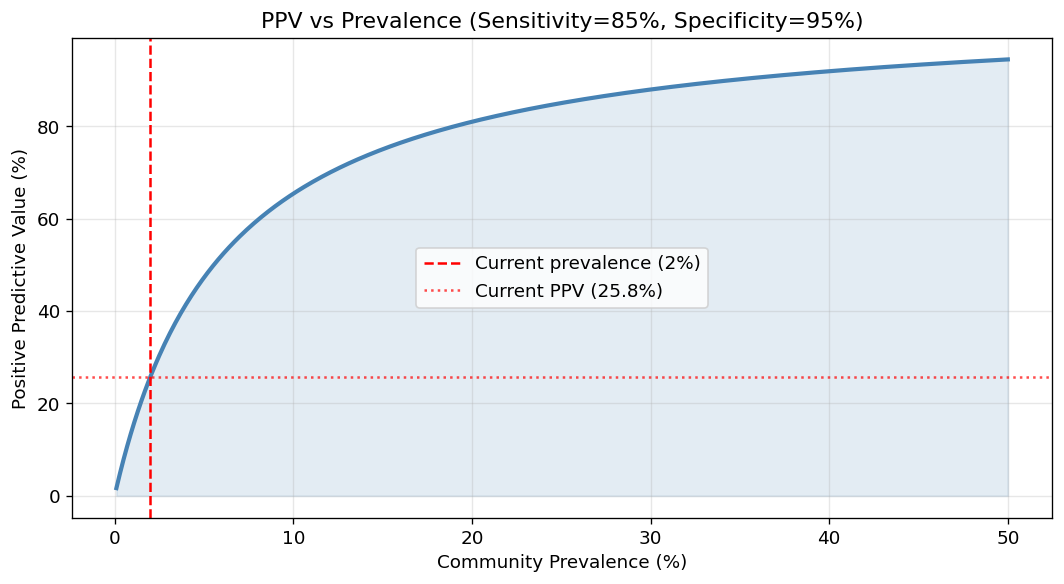

PPV at 2% prevalence:  25.8%
PPV at 10% prevalence: 65.4%
PPV at 30% prevalence: 87.9%


In [ ]:
# C.1 — PPV vs prevalence curve
prev_vals = np.linspace(0.001, 0.50, 500)

def bayes_PPV(prev, sens=sensitivity, spec=specificity):
    'Positive Predictive Value for given prevalence.'
    fpr = 1 - spec
    P_pos = sens * prev + fpr * (1 - prev)
    return sens * prev / P_pos

ppv_vals = bayes_PPV(prev_vals)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(prev_vals * 100, ppv_vals * 100, "steelblue", lw=2.5)
ax.axvline(prevalence * 100, color="red", ls="--", label=f"Current prevalence ({prevalence:.0%})")
ax.axhline(PPV * 100, color="red", ls=":", alpha=0.7, label=f"Current PPV ({PPV:.1%})")
ax.fill_between(prev_vals * 100, ppv_vals * 100, alpha=0.15, color="steelblue")
ax.set_xlabel("Community Prevalence (%)")
ax.set_ylabel("Positive Predictive Value (%)")
ax.set_title(f"PPV vs Prevalence (Sensitivity={sensitivity:.0%}, Specificity={specificity:.0%})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PPV at 2% prevalence:  {bayes_PPV(0.02):.1%}")
print(f"PPV at 10% prevalence: {bayes_PPV(0.10):.1%}")
print(f"PPV at 30% prevalence: {bayes_PPV(0.30):.1%}")

✏️ **Group Discussion:**

1. Why is the PPV only ~26% even though the test is 85% sensitive? Where do the false positives come from?
2. At what prevalence does the PPV reach 50%? Use your plot to estimate, then verify with Python.
3. Should health authorities use this test for population screening at 2% prevalence? What are the consequences of a false positive for the patient?

```
DISCUSSION:
1. The PPV is only ~26% because of the low community presence. The false positives (9800x0.95 = 490) come from having such a large community population not being infected compared to people who are infected (200x0.85 = 170). Therefore the PPV will still be a smaller population.

2. Estimate: ~5.5-6%
Calculation: 0.50 = 0.85P/0.05P + (1-P) x (1-0.85)
             0.50 = 0.85P/0.85P + 0.05(1-P)
             0.50 x (0.085P+0.05P(1-P) = 0.85P
             (x both sides by 2)
             0.85P + 0.05(1-P) = 1.7P
             0.85P + 0.05 - 0.05P = 1.7P
             0.8P + 0.05 = 1.7P
             0.05 = 1.7P - 0.8P
             0.05 = 0.9P
             P = 0.05/0.9
             P = 5.56%


3. Health authorities shouldn't be using this test for population screening at 2% prevelance. Consequecnes include using up valuable resources on patients that don't need them. It can cause psychological distress on patients believing they have an illness when they don't. And it can also cause triage burden on hospitals and other health care centres.
```


---
## ✅ Submission Exercise — Batch 3 (due Tuesday 29 September, 11:59 pm)

**Submit via LMS. Covers Weeks 7–9 (definite integrals, ODEs, probability).**

Work individually. Show all working. Write Python code where indicated.
Upload your **completed notebook (.ipynb)** to the LMS — do not submit screenshots.
        

In [ ]:

# Fill in your details before submitting
student_name   = "Sara Eastough"
student_number = "25206803"
print(f"Submission by: {student_name}  |  Student #{student_number}")


Submission by: Sara Eastough  |  Student #25206803



---
### Q1 — Consumer and Producer Surplus (Week 7)

A freshwater prawn market in the Ord River region has:
- Demand: $Q_d = 400 - 2P$ (kg/week)
- Supply: $Q_s = -60 + 3P$ (kg/week)

**(a)** Find the equilibrium price $P^*$ and quantity $Q^*$ algebraically.
        


**Answer (a):**

Qd=Qs
400-2P = -60+3P
400 = -60+5P
460 = 5P
P* = 460/5
P* = 92

Q* = 400-2(92) = 400-184
Q* = 216

        


**(b)** Derive the inverse demand and inverse supply functions.
        


**Answer (b):**

Qd:
Q = 400-2P
2P = 400-Q
Pd(Q) = 200-0.5Q

Qs:
Q = -60+3P
3P = Q+60
Ps(Q) = 1/3Q+20
        


**(c)** Calculate CS and PS using the triangle formulas. Show all working.
        


**Answer (c):**

CS:
200-0.5(0) = 200
200-92 = 108
CS = 1/2 x 216 x 108 = 11,664

PS:
20+1/3(0) = 20
92-20 = 72
PS = 1/2 x 216 x 72 = 7,776
        


**(d)** Verify CS and PS using numerical integration (`numpy.trapz`).
        

In [2]:

# Q1d — verify with integration
import numpy as np

def demand_P(Q):
    # inverse demand: P as a function of Q
    return 200 - 0.5 * Q

def supply_P(Q):
    # inverse supply: P as a function of Q
    return 20 + (1 / 3) * Q

# Equilibrium values calculated
P_star = 92
Q_star = 216

# Generate an array of quantity values from 0 up to the equilibrium quantity
# Using a high number of points (e.g., 1000) ensures precise numerical estimation
Q_grid = np.linspace(0, Q_star, 1000)

# Calculate the heights of the surplus areas at each quantity point
CS_heights = demand_P(Q_grid) - P_star
PS_heights = P_star - supply_P(Q_grid)

# Integrate using the trapezoidal rule
CS_verified = np.trapezoid(CS_heights, Q_grid)
PS_verified = np.trapezoid(PS_heights, Q_grid)

# Display results
print(f"Verified Consumer Surplus (CS): {CS_verified:,.2f}")
print(f"Verified Producer Surplus (PS): {PS_verified:,.2f}")


Verified Consumer Surplus (CS): 11,664.00
Verified Producer Surplus (PS): 7,776.00



---
### Q2 — Predator-Prey Dynamics (Week 8)

A quoll-rat system in the Pilbara:

$$\frac{dR}{dt} = 0.6R - 0.003RQ, \qquad \frac{dQ}{dt} = -0.2Q + 0.001RQ$$

where $R$ = rat population, $Q$ = quoll population.

**(a)** Find the coexistence equilibrium $(R^*, Q^*)$. Show your algebra.
        


**Answer (a):**   

0.6R-0.003RQ = 0
R(0.6-0.003Q) = 0
0.6-0.003Q = 0 => 0.003Q = 0.6
Q* = 0.6/0.003 = 200

-0.2Q+0.001RQ = 0
Q(-0.2+0.001R) = 0
-0.2+0.001R = 0 => 0.001R = 0.2
R* = 0.2/0.001 = 200

Coexistance equalibrium = (R*,Q*) = (200,200)


        


**(b)** Identify the rat nullcline and quoll nullcline. What does each represent biologically?
        


**Answer (b):**

R=0 - no rats
Q=200 - predator population size that keeps rat population stable.

Q=0 - no quolls
R=200 - minimum prey population size required to sustain quoll population.
        


**(c)** Simulate the system for 30 years starting from $R_0 = 500$, $Q_0 = 80$ using Euler's method (dt = 0.01). Plot both populations over time.
        

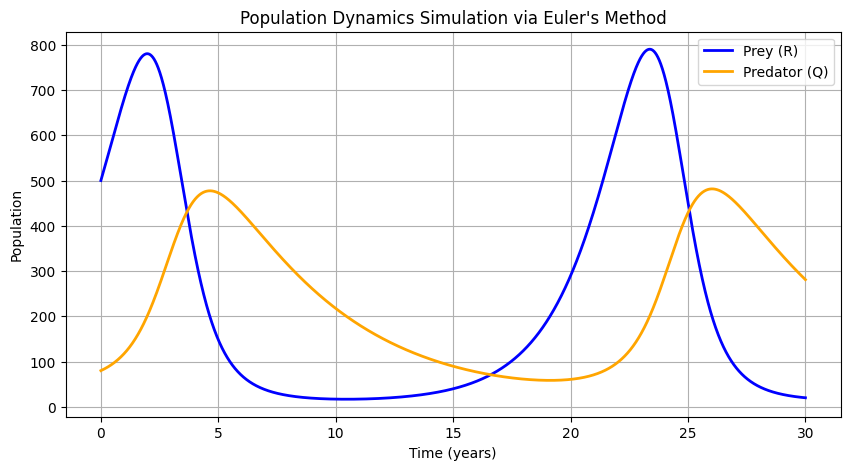

In [3]:

# Q2c — Euler method simulation
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Parameters
r_R = 0.6; a = 0.003; d_Q = 0.2; b = 0.001

# Simulation parameters
T = 30           # Total time in years
dt = 0.01        # Time step
N = int(T / dt)  # Number of steps

# Arrays to store time and population data
t = np.linspace(0, T, N + 1)
R = np.zeros(N + 1)
Q = np.zeros(N + 1)

# Initial conditions
R[0] = 500
Q[0] = 80

# Euler's method loop
for i in range(N):
    # Differential equations (Lotka-Volterra predator-prey model)
    dRdt = r_R * R[i] - a * R[i] * Q[i]
    dQdt = b * R[i] * Q[i] - d_Q * Q[i]

    # Update populations
    R[i+1] = R[i] + dRdt * dt
    Q[i+1] = Q[i] + dQdt * dt

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(t, R, label='Prey (R)', color='blue', linewidth=2)
plt.plot(t, Q, label='Predator (Q)', color='orange', linewidth=2)
plt.xlabel('Time (years)')
plt.ylabel('Population')
plt.title("Population Dynamics Simulation via Euler's Method")
plt.legend()
plt.grid(True)
plt.show()




**(d)** Do the populations oscillate or converge? Is the equilibrium reached?
        


**Answer (d):**

The populations oscillate and do not converge at any point. Equalibrium will never be reached because these populations are constantly cycling around each other (200,200).


---
### Q3 — Bayes' Theorem (Week 9)

A breast cancer screening test has sensitivity 90% and specificity 92%. Background prevalence in the 50–60 age group is 1.5%.

**(a)** Calculate $P(T^+)$ — the probability a randomly selected person tests positive.
        


**Answer (a):**

P(T+) = 0.9 x 0.015 + 0.08 x 0.985
P(T+) 9.23%
        


**(b)** Calculate the PPV using Bayes' theorem. Show each step.
        


**Answer (b):**

Bayes' theorem = P(D+ T+) = P(T+ D+)P(D+)/P(T+)
0.9 x 0.015/0.0923
0.0135/0.0923 = 0.1463
PPV = 14.63%
        


**(c)** Plot PPV vs prevalence for prevalence ranging from 0.1% to 20%. Annotate the 1.5% prevalence point.
        

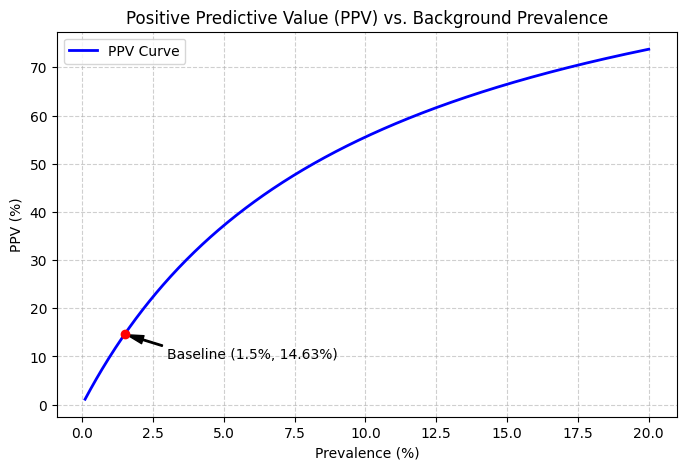

In [4]:

# Q3c — PPV vs prevalence
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sensitivity = 0.90
specificity = 0.92

# Generate prevalence tracking array from 0.1% to 20%
prevalence = np.linspace(0.001, 0.20, 500)

# Calculate PPV using Bayes' theorem expressed function
ppv = (sensitivity * prevalence) / ((sensitivity * prevalence) + ((1 - specificity) * (1 - prevalence)))

# Plotting settings
plt.figure(figsize=(8, 5))
plt.plot(prevalence * 100, ppv * 100, label='PPV Curve', color='blue', lw=2)

# Baseline background point marking
p_base = 0.015
ppv_base = (sensitivity * p_base) / ((sensitivity * p_base) + ((1 - specificity) * (1 - p_base)))
plt.scatter(p_base * 100, ppv_base * 100, color='red', zorder=5)
plt.annotate(f'Baseline (1.5%, {ppv_base*100:.2f}%)',
             xy=(p_base * 100, ppv_base * 100),
             xytext=(p_base * 100 + 1.5, ppv_base * 100 - 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.title('Positive Predictive Value (PPV) vs. Background Prevalence')
plt.xlabel('Prevalence (%)')
plt.ylabel('PPV (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()




**(d)** At what prevalence would PPV reach 50%? Solve algebraically or numerically.
        


**Answer (d):**

PPV = Sensitivity x Prevalance / Sensitivity x Prevalance + (1-Specifity) x (1-Prevalance)

0.9p = 0.08(1-p)
0.9p = 0.08 - 0.08p
0.98p =0.08

0.5 = 0.9 x p / (0.9xp) + (0.08x(1-p))
0.5 x [(0.9xp) + (0.08x(1-p))] = 0.9p
0.45p + 0.04(1-p) = 0.9p
0.45p + 0.04 - 0.04p = 0.9p
0.41p + 0.04 = 0.9p
0.04 = 0.9p - 0.41p
0.04 = 0.49p
p = 4/49
p = 0.0816
p = 8.16

Prevalance = 8.16%    